# Question A4

In this section, we will understand the utility of such a neural network in real world scenarios.

#### Please use the real record data named ‘record.wav’  as a test sample. Preprocess the data using the provided preprocessing script (data_preprocess.ipynb) and prepare the dataset.
Do a model prediction on the sample test dataset and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal batch size and optimal number of neurons.
Find the top 3 most important features on the model prediction for the test sample using SHAP. Plot the local feature importance with a force plot and explain your observations. (Refer to the documentation and these three useful references:
https://christophm.github.io/interpretable-ml-book/shap.html#examples-5,
https://towardsdatascience.com/deep-learning-model-interpretation-using-shap-a21786e91d16,  
https://medium.com/mlearning-ai/shap-force-plots-for-classification-d30be430e195)



1. Firstly, we import relevant libraries.

In [181]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from common_utils import set_seed

# setting seed
set_seed()

##### To reduce repeated code, place your
network (MLP defined in QA1)
torch datasets (CustomDataset defined in QA1)
loss function (loss_fn defined in QA1)
in a separate file called common_utils.py

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.


In [184]:
from common_utils import split_dataset, preprocess_dataset
from common_utils import MLP, loss_fn, CustomDataset, EarlyStopper
from common_utils import train_loop, test_loop

no_labels = 1
no_features = 77
no_hidden = 128

dropout_rate = 0.3

no_of_epochs = 200

learning_rate = 0.001
weight_decay = 0.0005
early_stopping_patience = 5
batch_size = 64

seed = 42
no_of_folds = 5

depth_of_layer = [1, 2, 3]
no_of_neuron = [64, 128, 256]

set_seed(seed)

In [186]:
def preprocess(df):
    x_train, y_train, x_test, y_test = split_dataset(df = df, columns_to_drop = ['filename', 'label'], test_size = 0.25, random_state = seed)
    
    return x_train, y_train, x_test, y_test

df_train = pd.read_csv('simplified.csv')
df_train['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = preprocess(df_train)

2. Install and import shap

In [10]:
!pip install shap

  Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.


In [11]:
import shap
print(shap.__version__)

0.51.0


3. Read the csv data preprocessed from 'record.wav', using variable name 'df', and fill the size of 'df' in 'size_row' and 'size_column'.

In [246]:
df = pd.read_csv('new_record.csv')
size_row, size_column = df.shape

df

,filename,tempo,total_beats,average_beats,chroma_stft_mean,chroma_stft_var,chroma_cq_mean,chroma_cq_var,chroma_cens_mean,chroma_cens_var,...,mfcc15_mean,mfcc15_var,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var
0,record.wav,[112.34714674],280,70.0,0.478361,0.111058,0.579547,0.091646,0.268037,0.01149,...,-4.068467,46.232433,-4.134901,53.040028,-0.942353,35.105545,-3.529712,54.78144,-3.722852,53.242016


 4.  Preprocess to obtain the test data, save the test data as numpy array.

In [250]:
def preprocess(X_train, df):
    df['tempo'] = df['tempo'].astype(str).str.strip('[]').astype(float)
    X_test = df.drop(columns=['filename'])
    
    #fit scaler on unscaled X_train, transform X_test
    X_train_scaled_eg, X_test_scaled_eg = preprocess_dataset(X_train.to_numpy(), X_test.to_numpy())
    
    return X_test_scaled_eg

In [252]:
X_test_scaled_eg = preprocess(X_train, df)

print(X_test_scaled_eg.shape)
print(X_test_scaled_eg)

(1, 77)
[[-2.84682022e-01 -8.52059694e-01 -1.09347538e+00 -1.36573050e+00
   2.09201208e+00  1.80729040e+00  1.40709880e+00  8.96958268e-01
  -9.09377300e-01 -5.35940462e-01 -3.00472893e-01 -3.09439700e+00
   3.28954415e+00  3.73885661e-01  2.30289336e+00 -1.00893504e+00
  -7.57640744e-02  1.31539653e+00  4.10606934e+00  1.46295636e+00
   1.79007431e+01 -5.05927881e+00 -4.25089321e+00  1.28121995e+00
   1.28121995e+00 -1.12826694e+00 -1.12826694e+00 -1.19408613e+00
  -1.25485157e+00  1.40420021e+00  1.31593072e+00  4.53197478e-02
  -8.17250797e-01 -7.00176475e-01  5.98321778e-02 -1.13624201e+00
  -8.81881032e-01 -3.09251269e+00  2.23033098e+00 -4.12904379e+00
   3.23908107e+00  1.26233342e+00  2.02922090e+00 -2.18891322e+00
   9.31713926e-01  1.01761004e+00 -7.38673061e-01 -1.13721020e+00
   3.07448116e-01  3.38921077e-01  5.06360784e-01 -3.56773444e-01
  -4.59125385e-01 -1.26518791e-01 -1.63734079e-03 -1.54582076e-02
  -1.08671076e+00 -4.58662764e-01 -1.63761431e+00  9.73722108e-01
  

In [254]:
print("Mean:", np.mean(X_test_scaled_eg)) 
print("Std :", np.std(X_test_scaled_eg)) 
print("Min :", np.min(X_test_scaled_eg))
print("Max :", np.max(X_test_scaled_eg))

Mean: -0.005338998969424541
Std : 2.6068874833807425
Min : -5.059278813213163
Max : 17.900743120160712


5. Do a model prediction on the sample test dataset and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal learning rate and optimal architecture. Note: Please define the variable of your final predicted label as 'pred_label'.

In [258]:
# Load the saved model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load('best_model.pth')
model = MLP(
    no_features  = checkpoint['no_features'],    # read from checkpoint
    hidden_layers=  checkpoint['architecture'],   # read from checkpoint
    no_labels    = 1,
    dropout_rate = dropout_rate
)
model.load_state_dict(checkpoint['model_state_dict'])  # load weights
model.to(device)
model.eval()

C:\Users\Owner\AppData\Local\Temp\ipykernel_1940\1181437758.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_model.pth')


MLP(
  (mlp_stack): Sequential(
    (0): Linear(in_features=77, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [260]:
# test on first sample of training data
X_sanity = torch.tensor(X_train_scaled[:1], dtype=torch.float32).to(device)
with torch.no_grad():
    out = model(X_sanity)
    print(f"Sanity check probability: {out.item():.4f}")

# Convert test data to tensor
X_test_tensor = torch.tensor(X_test_scaled_eg, dtype=torch.float32).to(device)

# Predict
with torch.no_grad():
    output     = model(X_test_tensor)
    prob       = output.item()
    pred_label = 1 if prob >= 0.5 else 0

print(f"Predicted Probability : {prob:.6f}")
print(f"Predicted Label       : {pred_label}")

Sanity check probability: 0.0626
Predicted Probability : 0.155524
Predicted Label       : 0


6. Find the most important features on the model prediction for your test sample using SHAP. Create an instance of the DeepSHAP which is called DeepExplainer using traianing dataset: https://shap.readthedocs.io/en/latest/generated/shap.DeepExplainer.html.

Plot the local feature importance with a force plot and explain your observations.  (Refer to the documentation and these three useful references:
https://christophm.github.io/interpretable-ml-book/shap.html#examples-5,
https://towardsdatascience.com/deep-learning-model-interpretation-using-shap-a21786e91d16,  
https://medium.com/mlearning-ai/shap-force-plots-for-classification-d30be430e195)


In [325]:
# ── Step 1: Background data ────────────────────────────────────────
X_train_scaled, _ = preprocess_dataset(X_train.to_numpy(), X_train.to_numpy())
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
background     = X_train_tensor[:150]

In [327]:
# ── Step 2: Create DeepExplainer ───────────────────────────────────
explainer   = shap.DeepExplainer(model, background)

In [329]:
# ── Step 3: Compute SHAP values ────────────────────────────────────
X_tensor    = torch.tensor(X_test_scaled_eg, dtype=torch.float32).to(device)
shap_values = explainer.shap_values(X_tensor)
shap_values_sample = shap_values[0]

In [331]:
# ── Step 4: Get feature names ──────────────────────────────────────
drop_cols  = [c for c in ['filename', 'label'] if c in df.columns]
features_names = df.drop(columns=drop_cols).columns.tolist()

In [333]:
# ── debug shape first ──────────────────────────────────────────────
print("shap_values shape       :", np.array(shap_values).shape)
print("shap_values_sample shape:", np.array(shap_values_sample).shape)

# ── flatten to 1D ─────────────────────────────────────────────────
shap_values_sample = np.array(shap_values_sample).flatten()

# ── Step 5: Top features by SHAP value ────────────────────────────
importance_df = pd.DataFrame({
    'feature'    : feat_names,
    'shap_value' : shap_values_sample,
    'abs_shap'   : np.abs(shap_values_sample)
}).sort_values('abs_shap', ascending=False)

shap_values shape       : (1, 77, 1)
shap_values_sample shape: (77, 1)


In [342]:
print("Top 5 Most Important Features:")
print("=" * 45)
print(f"{'Rank':<6} {'Feature':<25} {'SHAP Value':<12}")
print("=" * 45)
for rank, (_, row) in enumerate(importance_df.head(5).iterrows(), 1):
    direction = "(pushes positive)" if row['shap_value'] > 0 else "(pushes negative)"
    print(f"{rank:<6} {row['feature']:<25} {row['shap_value']:+.4f}  {direction}")
print("=" * 45)

Top 5 Most Important Features:
Rank   Feature                   SHAP Value  
1      spec_bw_var               +1.1168  (pushes positive)
2      cent_var                  -0.6756  (pushes negative)
3      contrast_mean             +0.3946  (pushes positive)
4      mfcc_var                  -0.2813  (pushes negative)
5      mfcc0_mean                -0.2661  (pushes negative)


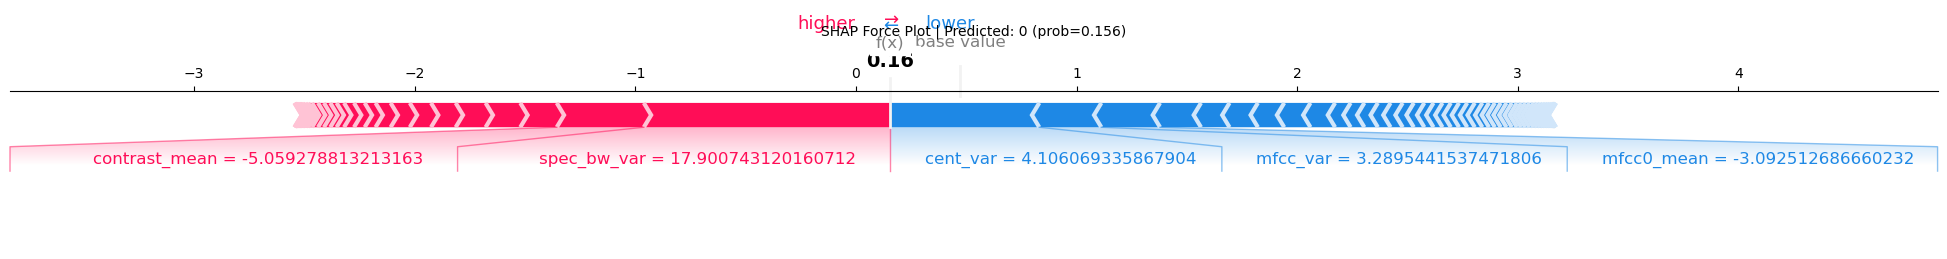

In [344]:
# ── Step 6: Force Plot ─────────────────────────────────────────────
shap.initjs()
force_plot = shap.force_plot(
    base_value    = explainer.expected_value[0],
    shap_values   = shap_values_sample,
    features      = X_test_scaled_eg[0],
    feature_names = feat_names,
    matplotlib    = True,
    show          = False
)

plt.title(f"SHAP Force Plot | Predicted: {pred_label} (prob={prob:.3f})",
          fontsize=10, pad=40)
plt.tight_layout()
plt.savefig('shap_force_plot.png', bbox_inches='tight', dpi=150)
plt.show()

### Explanation about the shap graph

The SHAP force plot above visualizes the local feature importance for the 
test sample from record.wav. The model predicted a probability of 0.156, 
resulting in a predicted label of 0 (Negative).

The base value of 0.00 represents the average model output over the 
background training dataset, serving as the reference point for the 
prediction.

From the force plot, the features are split into two opposing forces:

> **Red features (pushing prediction higher - towards positive):**
> 1. spec_bw_var = 17.90 — the largest positive contributor, strongly 
   pushing the prediction to the right above the base value.
> 2. contrast_mean = -5.06 — also contributes positively, adding to the 
   upward push on the predicted probability.

> **Blue features (pushing prediction lower - towards negative):**
> 1. cent_var = 4.11 — the strongest negative contributor, pushing the 
   prediction significantly to the left below the base value.
> 2. mfcc_var = 3.29 — also contributes negatively, further suppressing 
   the predicted probability.
> 3. mfcc0_mean = -3.10 — an additional negative contributor reinforcing 
   the downward push.

Although spec_bw_var and contrast_mean create a strong positive push, 
the combined negative contributions from cent_var, mfcc_var and mfcc0_mean 
outweigh them, resulting in a final predicted probability of 0.156 which 
remains below the 0.5 decision threshold, classifying this sample as 
Negative (label = 0).
